# Pre-Processing

### Install libraries & Load the dataset

In [2]:
import pandas as pd
import numpy as np
import os
import glob
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

## Dataset:
The depresjon dataset is a collection of motor activity data token from wrist actigraphy recorded from indivisuals, some are patients ( condition group ) diagnosed with bipolar, unipolar & depression, and some are healthy ( control group ).

The dataset contains 55 files:

23 Condition ( Patients )

32 Control ( Normal )

Scores file containing metadata & clinical / demographic data

In [3]:
SCORES = pd.read_csv("scores.csv")
CONDITION = glob.glob("condition/*.csv")
CONTROL = glob.glob("control/*.csv")

In [4]:
SCORES.head()

,number,days,gender,age,afftype,melanch,inpatient,edu,marriage,work,madrs1,madrs2
0,condition_1,11,2,35-39,2.0,2.0,2.0,6-10,1.0,2.0,19.0,19.0
1,condition_2,18,2,40-44,1.0,2.0,2.0,6-10,2.0,2.0,24.0,11.0
2,condition_3,13,1,45-49,2.0,2.0,2.0,6-10,2.0,2.0,24.0,25.0
3,condition_4,13,2,25-29,2.0,2.0,2.0,11-15,1.0,1.0,20.0,16.0
4,condition_5,13,2,50-54,2.0,2.0,2.0,11-15,2.0,2.0,26.0,26.0


In [5]:
def load_activity():
    frames = []
    for f in CONDITION:
        df = pd.read_csv(f)
        df['number'] = os.path.basename(f).replace(".csv","")
        df['group'] = "condition"
        frames.append(df)

    for f in CONTROL:
        df = pd.read_csv(f)
        df['number'] = os.path.basename(f).replace(".csv","")
        df['group'] = "control"
        frames.append(df)

    return pd.concat(frames, ignore_index=True)

activity = load_activity()
scores = SCORES

activity.head()

,timestamp,date,activity,number,group
0,2005-03-08 10:00:00,2005-03-08,0,condition_12,condition
1,2005-03-08 10:01:00,2005-03-08,0,condition_12,condition
2,2005-03-08 10:02:00,2005-03-08,0,condition_12,condition
3,2005-03-08 10:03:00,2005-03-08,3,condition_12,condition
4,2005-03-08 10:04:00,2005-03-08,0,condition_12,condition


## Date Formating

In [6]:
# Check out the formating of the dates: strict to the same date formats
activity['datetime'] = pd.to_datetime(
    activity['timestamp'],
    format="%Y-%m-%d %H:%M:%S",
    errors='coerce'
)
activity.head()

# Remove Timestamp & Date columns
activity = activity.drop(columns=['timestamp', 'date'])

## Basic Cleaning

In [7]:
# Remove negative activity values
activity_df = activity[
    activity['activity'] >= 0
]

# Sort values by patient and time
activity_df = activity.sort_values(
    ['number', 'datetime']
)

activity_df.head()

,activity,number,group,datetime
43702,0,condition_1,condition,2003-05-07 12:00:00
43703,143,condition_1,condition,2003-05-07 12:01:00
43704,0,condition_1,condition,2003-05-07 12:02:00
43705,20,condition_1,condition,2003-05-07 12:03:00
43706,166,condition_1,condition,2003-05-07 12:04:00


## Signal Smoothing

In [8]:
# Smooth noisy activity signal using moving average

activity_df['activity_smooth'] = (

    activity_df
    .groupby('number')['activity']

    .rolling(window=5)

    .mean()

    .reset_index(level=0, drop=True)

)

# Fill missing values
activity_df['activity_smooth'] = (

    activity_df['activity_smooth']

    .fillna(activity_df['activity'])

)

activity_df.head()

,activity,number,group,datetime,activity_smooth
43702,0,condition_1,condition,2003-05-07 12:00:00,0.0
43703,143,condition_1,condition,2003-05-07 12:01:00,143.0
43704,0,condition_1,condition,2003-05-07 12:02:00,0.0
43705,20,condition_1,condition,2003-05-07 12:03:00,20.0
43706,166,condition_1,condition,2003-05-07 12:04:00,65.8


## Time Features

In [9]:
# Extract hour from datetime

activity_df['hour'] = (
    activity_df['datetime'].dt.hour
)

# Extract date only

activity_df['date'] = (
    activity_df['datetime'].dt.date
)

activity_df.head()

,activity,number,group,datetime,activity_smooth,hour,date
43702,0,condition_1,condition,2003-05-07 12:00:00,0.0,12,2003-05-07
43703,143,condition_1,condition,2003-05-07 12:01:00,143.0,12,2003-05-07
43704,0,condition_1,condition,2003-05-07 12:02:00,0.0,12,2003-05-07
43705,20,condition_1,condition,2003-05-07 12:03:00,20.0,12,2003-05-07
43706,166,condition_1,condition,2003-05-07 12:04:00,65.8,12,2003-05-07


# Feature Extraction

### Extract behavioral features for each patient

In [10]:
behavior_features = activity_df.groupby('number').agg(

    # Average activity
    mean_activity = (
        'activity_smooth',
        'mean'
    ),

    # Activity variability
    std_activity = (
        'activity_smooth',
        'std'
    ),

    # Maximum activity
    max_activity = (
        'activity_smooth',
        'max'
    ),

    # Inactivity ratio
    inactivity_ratio = (
        'activity_smooth',
        lambda x: (x < 50).mean()
    ),

    # Night activity
    night_activity = (
        'activity_smooth',

        lambda x: x[
            (
                activity_df.loc[x.index, 'hour'] >= 22
            ) |
            (
                activity_df.loc[x.index, 'hour'] <= 5
            )
        ].mean()
    ),

    # Morning activity
    morning_activity = (
        'activity_smooth',

        lambda x: x[
            (
                activity_df.loc[x.index, 'hour'] >= 6
            ) &
            (
                activity_df.loc[x.index, 'hour'] <= 11
            )
        ].mean()
    )

).reset_index()

behavior_features.head()

,number,mean_activity,std_activity,max_activity,inactivity_ratio,night_activity,morning_activity
0,condition_1,146.932834,256.233910,3015.0,0.543452,27.924427,127.835382
1,condition_10,289.622603,353.225402,2792.8,0.390629,66.943028,297.483585
2,condition_11,129.383393,248.644681,2850.6,0.641192,81.626875,47.888371
3,condition_12,151.444250,233.264987,2446.8,0.525940,62.038972,93.070652
4,condition_13,221.348746,291.145177,1941.8,0.444230,108.420509,243.788964


### Circadian Rhythm Feature

#### Measure sleep/wake rhythm disruption

In [11]:
daily_pattern = activity_df.groupby(

    ['number', 'hour']

)['activity_smooth'].mean().reset_index()

circadian_std = daily_pattern.groupby('number')[

    'activity_smooth'

].std().reset_index()

circadian_std.columns = [

    'number',
    'circadian_disruption'

]

# Merge feature
behavior_features = behavior_features.merge(

    circadian_std,
    on='number'

)

behavior_features.head()

,number,mean_activity,std_activity,max_activity,inactivity_ratio,night_activity,morning_activity,circadian_disruption
0,condition_1,146.932834,256.233910,3015.0,0.543452,27.924427,127.835382,125.935935
1,condition_10,289.622603,353.225402,2792.8,0.390629,66.943028,297.483585,203.768996
2,condition_11,129.383393,248.644681,2850.6,0.641192,81.626875,47.888371,88.028182
3,condition_12,151.444250,233.264987,2446.8,0.525940,62.038972,93.070652,105.616098
4,condition_13,221.348746,291.145177,1941.8,0.444230,108.420509,243.788964,122.960039


### Check Missing Files

In [12]:
behavior_features.isnull().sum()

,0
number,0
mean_activity,0
std_activity,0
max_activity,0
inactivity_ratio,0
night_activity,0
morning_activity,0
circadian_disruption,0


### Select Features

In [13]:
features = [

    'mean_activity',
    'std_activity',
    'max_activity',
    'inactivity_ratio',
    'night_activity',
    'morning_activity',
    'circadian_disruption'

]

X = behavior_features[features].fillna(0)

X.head()

,mean_activity,std_activity,max_activity,inactivity_ratio,night_activity,morning_activity,circadian_disruption
0,146.932834,256.233910,3015.0,0.543452,27.924427,127.835382,125.935935
1,289.622603,353.225402,2792.8,0.390629,66.943028,297.483585,203.768996
2,129.383393,248.644681,2850.6,0.641192,81.626875,47.888371,88.028182
3,151.444250,233.264987,2446.8,0.525940,62.038972,93.070652,105.616098
4,221.348746,291.145177,1941.8,0.444230,108.420509,243.788964,122.960039


## Feature Scaling

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(55, 7)


### Find Best Number of Clusters

In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 8):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f"K = {k}, Score = {score:.3f}")

K = 2, Score = 0.360
K = 3, Score = 0.272
K = 4, Score = 0.292
K = 5, Score = 0.257
K = 6, Score = 0.219
K = 7, Score = 0.238


### Plot Silhouette Scores

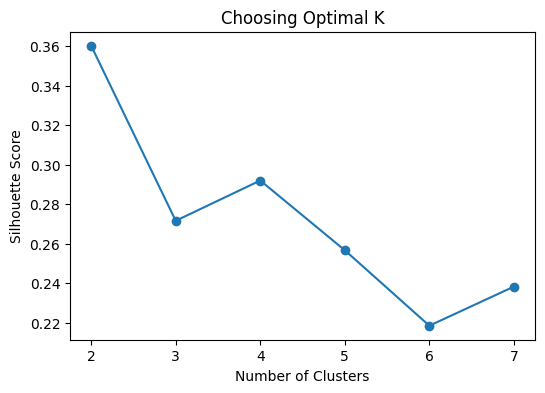

In [16]:
plt.figure(figsize=(6,4))

plt.plot(
    range(2,8),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.title("Choosing Optimal K")

plt.show()

### Final K-Means Clustering

In [17]:
kmeans = KMeans(

    n_clusters=4,
    random_state=42

)

behavior_features['cluster'] = (

    kmeans.fit_predict(X_scaled)

)

behavior_features.head()

,number,mean_activity,std_activity,max_activity,inactivity_ratio,night_activity,morning_activity,circadian_disruption,cluster
0,condition_1,146.932834,256.233910,3015.0,0.543452,27.924427,127.835382,125.935935,1
1,condition_10,289.622603,353.225402,2792.8,0.390629,66.943028,297.483585,203.768996,0
2,condition_11,129.383393,248.644681,2850.6,0.641192,81.626875,47.888371,88.028182,1
3,condition_12,151.444250,233.264987,2446.8,0.525940,62.038972,93.070652,105.616098,1
4,condition_13,221.348746,291.145177,1941.8,0.444230,108.420509,243.788964,122.960039,1


## PCA Dimensionality Reduction

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

behavior_features['pca1'] = X_pca[:,0]

behavior_features['pca2'] = X_pca[:,1]

behavior_features.head()

,number,mean_activity,std_activity,max_activity,inactivity_ratio,night_activity,morning_activity,circadian_disruption,cluster,pca1,pca2
0,condition_1,146.932834,256.233910,3015.0,0.543452,27.924427,127.835382,125.935935,1,-0.992699,0.020171
1,condition_10,289.622603,353.225402,2792.8,0.390629,66.943028,297.483585,203.768996,0,2.306741,-0.820198
2,condition_11,129.383393,248.644681,2850.6,0.641192,81.626875,47.888371,88.028182,1,-1.608567,0.442952
3,condition_12,151.444250,233.264987,2446.8,0.525940,62.038972,93.070652,105.616098,1,-1.137056,-0.416990
4,condition_13,221.348746,291.145177,1941.8,0.444230,108.420509,243.788964,122.960039,1,0.781944,-1.212576


## Visualize Clusters

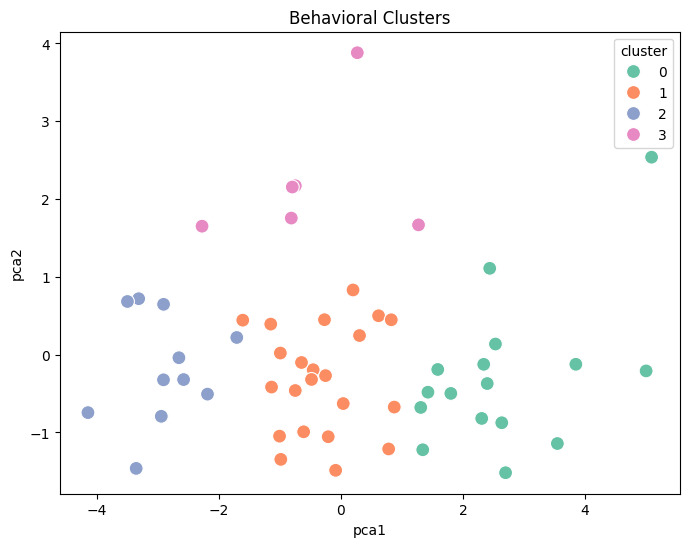

In [19]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    data=behavior_features,

    x='pca1',
    y='pca2',

    hue='cluster',

    palette='Set2',

    s=100

)

plt.title("Behavioral Clusters")

plt.show()

## Cluster Summary

In [20]:
cluster_summary = (

    behavior_features

    .groupby('cluster')[features]

    .mean()

)

cluster_summary

,mean_activity,std_activity,max_activity,inactivity_ratio,night_activity,morning_activity,circadian_disruption
cluster,,,,,,,
0,291.422694,388.194917,3250.387500,0.407959,112.364821,292.510005,177.999395
1,176.651353,275.670222,2661.581818,0.525188,69.977446,170.929666,115.164687
2,86.857271,177.454823,2148.181818,0.697507,38.924303,95.420938,54.612909
3,156.284302,340.582351,5033.166667,0.704904,56.993266,155.220529,104.306055


## Interrupt Clusters

In [21]:
for cluster_id in sorted(

    behavior_features['cluster'].unique()

):

    print("\n======================")
    print(f"CLUSTER {cluster_id}")
    print("======================")

    subset = behavior_features[

        behavior_features['cluster'] == cluster_id

    ]

    print(

        subset[features].mean()

    )


CLUSTER 0
mean_activity            291.422694
std_activity             388.194917
max_activity            3250.387500
inactivity_ratio           0.407959
night_activity           112.364821
morning_activity         292.510005
circadian_disruption     177.999395
dtype: float64

CLUSTER 1
mean_activity            176.651353
std_activity             275.670222
max_activity            2661.581818
inactivity_ratio           0.525188
night_activity            69.977446
morning_activity         170.929666
circadian_disruption     115.164687
dtype: float64

CLUSTER 2
mean_activity             86.857271
std_activity             177.454823
max_activity            2148.181818
inactivity_ratio           0.697507
night_activity            38.924303
morning_activity          95.420938
circadian_disruption      54.612909
dtype: float64

CLUSTER 3
mean_activity            156.284302
std_activity             340.582351
max_activity            5033.166667
inactivity_ratio           0.704904
night_activ

## Save Results

In [22]:
behavior_features.to_csv(

    "behavior_profiles_results.csv",

    index=False

)

print("Results saved successfully.")

Results saved successfully.
